Chain of Thoughts with RAG

user query
- step 1: decompose question -> sub-steps(reason)
- step 2: retrieve docs per step (act)
- step 3: combine context (observe)
- step 4: final answer generation (reflect)

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END

Preparing vectorstore and retriever

In [2]:
docs = TextLoader("research_notes.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks,embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Initializing the LLM

In [3]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000024DE2C32F60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000024DE4CBCFB0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Graph State Definition

In [4]:
class RagCOTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

Node Definition (3 nodes)
- plan sub-questions nodes (builds the steps/sub questions)
- retrieve for each step/sub-question
- answer generation node

In [ ]:
def plan_steps(state: RagCOTState) -> RagCOTState:
    prompt = f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result = llm.invoke(prompt).content
    subqs = [line.strip("- ") for line in result.split("\n") if line.strip()]
    return state.model_copy(update={"sub_steps":subqs})

def retrieve_per_step(state: RagCOTState) -> RagCOTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs":all_docs})

def generate_answer(state: RagCOTState) -> RagCOTState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""You are answering a complex question using reasoning and retrieved documents.
    Question: {state.question}
Relevant Information: {context}
Now synthesize a well-reasoned final answer.
"""
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":result})

Building the graph

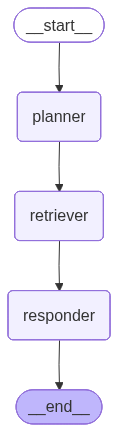

In [6]:
builder = StateGraph(RagCOTState)

builder.add_node("planner",plan_steps)
builder.add_node("retriever",retrieve_per_step)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

testing the COT RAG

In [8]:
query = "Tell me something about Project Falcon and how well are its prototypes working?"
state = RagCOTState(question=query)
final = graph.invoke(state)
print(f"Question: {query}")
print(f"Answer: {final['answer']}")
print(f"Reasoning Steps: {final['sub_steps']}")

Question: Tell me something about Project Falcon and how well are its prototypes working?
Answer: After analyzing the provided research notes from Orion Dynamics, I can conclude the following information about Project Falcon:

**Project Overview:**
Project Falcon is a project with a clear goal, as indicated by the consistent notes across multiple documents. The project's objectives are not explicitly stated, but based on the notes, we can infer that it involves developing a prototype with a high accuracy rate (91.7%) and exploring potential markets in Logistics, Retail, and Manufacturing.

**Prototype Performance:**
The prototype's accuracy is consistently reported at 91.7%, indicating a stable and high-performance model. Additionally, the development team has explored alternative models, such as "Nova-3," which consumed 18% less GPU memory, indicating potential improvements in resource efficiency.

**Customer Feedback and Interviews:**
The team has completed 37 customer interviews, wh